In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, skew, mannwhitneyu, shapiro
import statsmodels.stats.power as smp
import seaborn as sns

In [2]:
# Load the data.
df = pd.read_excel('Time_for_Bac_Fix_Comparison.xlsx')
df.head()

,Chemotaxis,Diffusion
0,16634,19759
1,22472,21205
2,15586,24775
3,15735,20404
4,15363,19818


### Descriptive Statistics

- Chemotaixs: in this case means the unaltered model with the chemotaxis equation.
- Diffusion: is the model with just the diffusion section for run and tumble, (exp(-r)).
- All units are in seconds.

In [3]:
df.describe()

,Chemotaxis,Diffusion
count,100.000000,100.000000
mean,17026.290000,20023.940000
std,1781.903507,2562.553859
min,12418.000000,6782.000000
25%,15948.250000,18798.750000
50%,16849.500000,19853.000000
75%,17738.500000,21155.500000
max,23383.000000,27235.000000


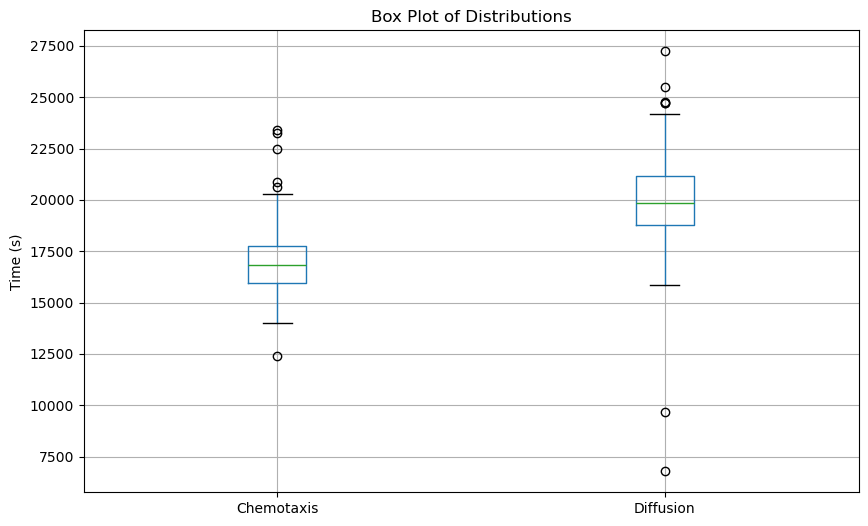

In [4]:
# Step 1: Visualize the Data
plt.figure(figsize=(10, 6))
df.boxplot()
plt.title('Box Plot of Distributions')
plt.ylabel('Time (s)')
plt.show()

### Data Cleaning

In [5]:
# Removing Outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
# Remove outliers
df_cleaned = df.copy()
df_cleaned['Chemotaxis'] = remove_outliers(df, 'Chemotaxis')['Chemotaxis']
df_cleaned['Diffusion'] = remove_outliers(df, 'Diffusion')['Diffusion']
df_cleaned.describe()

,Chemotaxis,Diffusion
count,94.000000,93.000000
mean,16804.255319,19989.279570
std,1277.577773,1544.066253
min,14020.000000,15866.000000
25%,15876.750000,18818.000000
50%,16801.000000,19818.000000
75%,17560.500000,20854.000000
max,20268.000000,24203.000000


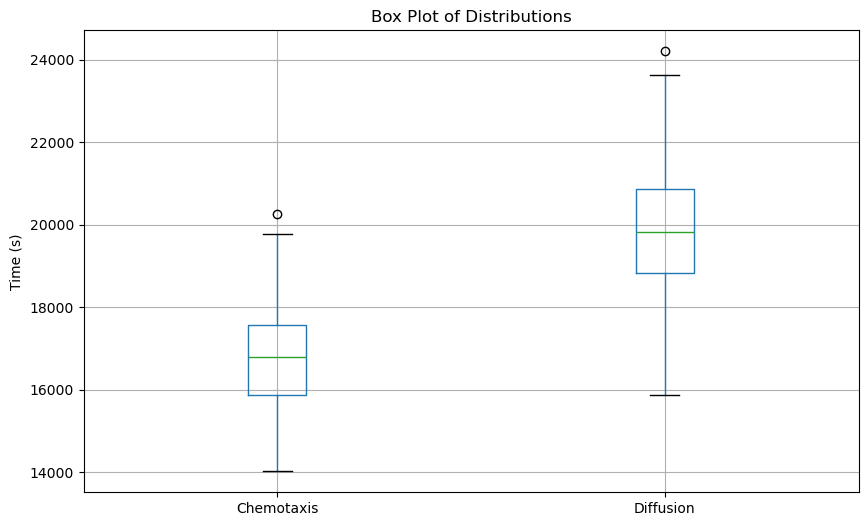

In [6]:
# Visualize the Data
plt.figure(figsize=(10, 6))
df_cleaned.boxplot()
plt.title('Box Plot of Distributions')
plt.ylabel('Time (s)')
plt.show()

Letter-value plots (boxenplots) start with the median (Q2, 50th percentile) as the centerline. Each successive level outward contains half of the remaining data. So the first two sections out from the centerline contain 50% of the data. After that, the next two sections contain 25% of the data. This continues until we are at the outlier level. Each level out is shaded lighter. There are 4 methods for calculating outliers (described in the paper and available in seaborn). The default is to end up with around 5-8 outliers in each tail.

Text(0, 0.5, 'Time (s)')

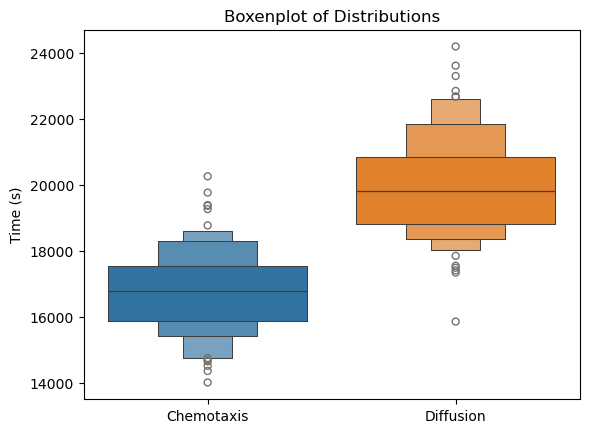

In [7]:
sns.boxenplot(data=df_cleaned)
plt.title('Boxenplot of Distributions')
plt.ylabel('Time (s)')

### Data Normalization and Histograms

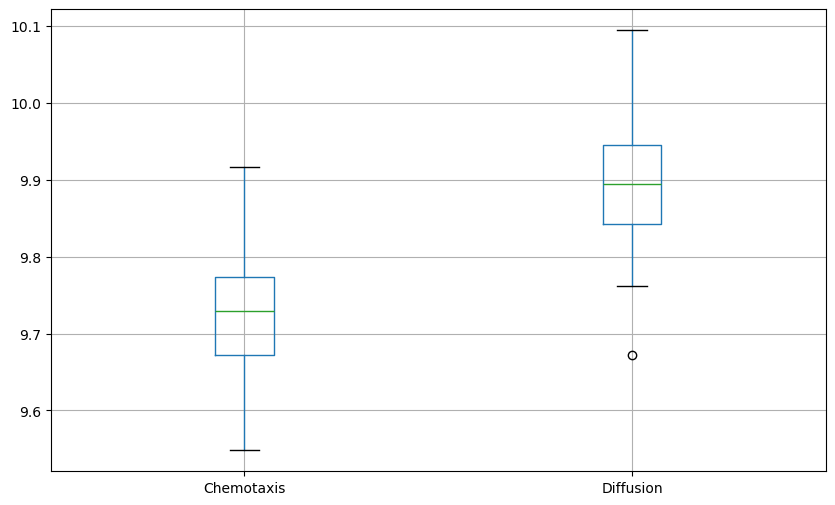

In [8]:
normalized_df_cleaned = df_cleaned.apply(lambda x: np.log(x))

# Visualize the Data
plt.figure(figsize=(10, 6))
normalized_df_cleaned.boxplot()
plt.show()

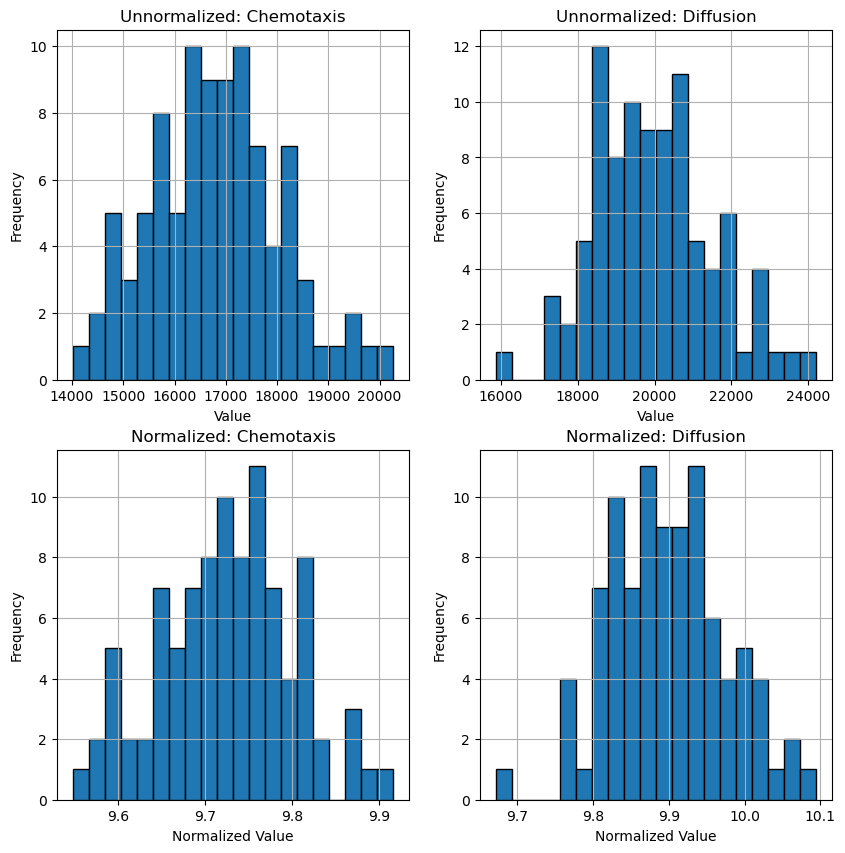

In [9]:
normalized_df_cleaned = df_cleaned.apply(lambda x: np.log(x))

# Number of columns to plot
num_columns = len(df_cleaned.columns)

# Create subplots
fig, axs = plt.subplots(2, num_columns, figsize=(5 * num_columns, 10))

# Ensure axs is 2-dimensional, even if there is only one column
if num_columns == 1:
    axs = np.array([[axs[0]], [axs[1]]])

# Plot histograms for each column in unnormalized data
for i, column in enumerate(df_cleaned.columns):
    df_cleaned[column].hist(ax=axs[0, i], bins=20, edgecolor='k')
    axs[0, i].set_title(f'Unnormalized: {column}')
    axs[0, i].set_xlabel('Value')
    axs[0, i].set_ylabel('Frequency')

# Plot histograms for each column in normalized data
for i, column in enumerate(normalized_df_cleaned.columns):
    normalized_df_cleaned[column].hist(ax=axs[1, i], bins=20, edgecolor='k')
    axs[1, i].set_title(f'Normalized: {column}')
    axs[1, i].set_xlabel('Normalized Value')
    axs[1, i].set_ylabel('Frequency')

### Power Analysis

**Comparing Normal Equation data to others.**

Comparing the chemotaxis data, (unaltered model), with the diffusion model.

In [10]:
# Calculate Skewness of a data set.
skew_chemotaxis = skew(df['Chemotaxis'].dropna())
skew_diffusion = skew(df['Diffusion'].dropna())

# Mann-Whitney U Test
u_stat, p_value_u = mannwhitneyu(df['Chemotaxis'].dropna(), df['Diffusion'].dropna())

skew_chemotaxis, skew_diffusion, u_stat, p_value_u

(1.0777454625937706, -1.504506149354982, 1028.0, 2.9010444834296846e-22)

Skewness:
- Both distributions are skewed, as one can tell by their score.
- Chemotaxis: 1.078
- The distribution is skewed to the right.
- Diffusion: -1.505
- The distribution is skewed to the left.

Median:
- Chemotaxis: 16801.0 s
- Diffusion: 19818.0 s

Mann-Whitney U Test:
- P-value: The the extremely low p-value is less than the common significance level of 0.05.  We can safely conclude that the null hypothesis is rejected and there is significant differences between the two distributions.

Conclusion:
    There is significant differences between the two distributions, and the time for fixing with chemotaxis is more likely to be lower as the median is lower than diffusion.

**The Shapiro-Wilk test shows the data is normally distributed, just the Mann-Whiteney U Test**

In [11]:
# Shapiro-Wilk Test
shapiro_chemotaxis = shapiro(df['Chemotaxis'].dropna())
shapiro_diffusion = shapiro(df['Diffusion'].dropna())

shapiro_chemotaxis, shapiro_diffusion

(ShapiroResult(statistic=0.9273199998344358, pvalue=3.517940736043756e-05),
 ShapiroResult(statistic=0.8420494673632595, pvalue=6.09653310069988e-09))

In [12]:
# T-Test
t_stat, p_value_u = ttest_ind(df['Chemotaxis'].dropna(), df['Diffusion'].dropna())

t_stat, p_value_u

(-9.604171992630267, 3.583448313660289e-18)

**Conclusion:**

The median of chemotaxis is lower than diffusion:
- Chemotaxis: 16801.0 s
- Diffusion: 19818.0 s

    The largest factor for how quickly a mutant will fix into a population is the stochastic Poisson distribution which determines the rate of mutation, and just as importantly, the proximity of a mutation occuring.  A mutation occuring near or within the antibiotic alongside how quickly that mutant migrates towards the area to fix in a low wildtype population is the greatest variable for time.  The reason for the increased variability in both distributions of mutant fixation time is primarily due to this reason.  This variability is partially mitigated by removing outliers > 1.5*IQR.

    Even with the increased variability, chemotaxis is shown to enhance time to fixation.  The magnitude of this effect is lessened by the model being one dimensional, as random diffusion away from higher population concentrations is still directed up the antibiotic gradient.  If this model was increased to 2 dimensions, chemotaxis would play a significantly greater effect on directed migration towards food.

### Sample Size

In [14]:
# Given data
mean_chemotaxis = 21746.51
std_chemotaxis = 3695.82
n_chemotaxis = 94

mean_diffusion = 26221.18
std_diffusion = 4155.32
n_diffusion = 93

# Calculate pooled standard deviation
s_pooled = np.sqrt(((n_chemotaxis - 1) * std_chemotaxis**2 + (n_diffusion - 1) * std_diffusion**2) / (n_chemotaxis + n_diffusion - 2))

# Calculate effect size (Cohen's d)
effect_size = abs(mean_diffusion - mean_chemotaxis) / s_pooled

# Perform power analysis
alpha = 0.05
power = 0.80

analysis = smp.TTestIndPower()
required_sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')

effect_size, required_sample_size

(1.1382894699053023, 13.148457806590313)

Approximately 13 samples per group are needed to detect a statistical significance.  The sample sizes are significant.